In [4]:
# ============================================================
# INSTALL DEPENDENCIES (Optional)
# ============================================================
# !pip install pandas numpy matplotlib seaborn

# ============================================================
# CELL 2 — IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [5]:
# ============================================================
# CELL 3 — DATASET PATH
# ============================================================

DATASET_PATH = "../../parquet_exports_v2/gold_ticket_similarity_v2.parquet"

print("Dataset path:", DATASET_PATH)


Dataset path: ../../parquet_exports_v2/gold_ticket_similarity_v2.parquet


In [6]:
# ============================================================
# CELL 4 — LOAD DATASET
# ============================================================
df = pd.read_parquet(DATASET_PATH)

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

df.head()


DATASET LOADED
Rows    : 108,536
Columns : 47


,rag_id,problem_text,solution_text,category,priority,language,product,queue,software_version,region,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,priority_tier,urgency_tier,impact_tier,triage_priority,escalation_risk_level,age_severity,customer_type,resolution_time_hours,waiting_duration,first_response_time_hours,sla_risk_score,escalation_probability,is_sla_breached,is_escalated,issue_complexity_score,customer_satisfaction_score,customer_tenure_months,previous_tickets,customer_segment,subscription_type,operating_system,browser,followup_count,avg_followup_content_length,source_dataset,created_at,resolved_at,source_system,source_id
0,45d0726cc395d2b3a2b8c9899523e1dc,I am unable to access my account after enterin...,Security settings updated and customer notifie...,performance issue,critical,french,Subscription Service,NaN,NaN,europe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,critical,None,None,medium,low,low,frequent,0.00,None,38.20,3.75,2.25,1,0,4.0,2.0,19.0,19.0,Individual,enterprise,linux,edge,0,0.0,customer_support_tickets_200k,2022-09-08,2022-09-08,customer_support_tickets_200k,383
1,504f35fd3b03f048a1984f89fffb08e1,I would like to request a refund for the recen...,Explained billing breakdown and clarified appl...,login issue,medium,french,E-commerce Store,NaN,NaN,north america,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,medium,None,None,medium,low,high,frequent,127.87,None,35.94,2.80,1.95,1,0,2.0,1.0,35.0,20.0,Corporate,free,macos,chrome,0,0.0,customer_support_tickets_200k,2023-09-25,2023-09-28,customer_support_tickets_200k,710
2,db7bc1e2f75fa986ee832c31e320a2de,There seems to be a discrepancy in my billing ...,Provided step-by-step troubleshooting instruct...,refund request,high,english,Cloud Storage,NaN,NaN,africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,high,None,None,high,low,low,frequent,20.94,None,18.89,4.00,2.60,0,0,7.0,1.0,46.0,18.0,Small Business,free,ios,safari,0,0.0,customer_support_tickets_200k,2023-06-21,2023-06-21,customer_support_tickets_200k,1031
3,01d7f2addbcc200f88368695230ea06e,The system is not syncing data across devices ...,Bug logged internally and workaround shared wi...,payment problem,low,chinese,Analytics Dashboard,NaN,NaN,north america,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low,None,None,medium,low,critical,new,63.57,None,14.06,2.95,3.25,0,1,6.0,2.0,54.0,0.0,Corporate,basic,linux,firefox,0,0.0,customer_support_tickets_200k,2023-03-13,2023-03-25,customer_support_tickets_200k,1114
4,aa219338e9e467aadb53d3d1a9026de7,I am unable to access my account after enterin...,Provided step-by-step troubleshooting instruct...,security concern,low,german,Cloud Storage,NaN,NaN,australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low,None,None,medium,low,critical,frequent,159.59,None,36.16,3.30,3.25,1,1,7.0,5.0,29.0,19.0,Corporate,basic,linux,NaN,0,0.0,customer_support_tickets_200k,2024-10-12,2024-10-21,customer_support_tickets_200k,1616


In [7]:
# ============================================================
# CELL 5 — MEMORY USAGE
# ============================================================
memory_mb = df.memory_usage(deep=True).sum() / 1024**2

print("=" * 60)
print("MEMORY USAGE")
print("=" * 60)

print(f"Dataset Memory Usage: {memory_mb:.2f} MB")

MEMORY USAGE
Dataset Memory Usage: 103.48 MB


In [8]:
# ============================================================
# CELL 6 — COLUMN OVERVIEW
# ============================================================

print("=" * 60)
print("COLUMN OVERVIEW")
print("=" * 60)

df.info()

COLUMN OVERVIEW
<class 'pandas.DataFrame'>
RangeIndex: 108536 entries, 0 to 108535
Data columns (total 47 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   rag_id                       108536 non-null  str    
 1   problem_text                 108536 non-null  str    
 2   solution_text                108536 non-null  str    
 3   category                     108536 non-null  str    
 4   priority                     108536 non-null  str    
 5   language                     108536 non-null  str    
 6   product                      79999 non-null   str    
 7   queue                        28537 non-null   str    
 8   software_version             28537 non-null   float64
 9   region                       79999 non-null   str    
 10  tag_1                        28537 non-null   str    
 11  tag_2                        28524 non-null   str    
 12  tag_3                        28403 non-null   str    

In [9]:
# ============================================================
# CELL 7 — DATA TYPES SUMMARY
# ============================================================
dtype_summary = (
    df.dtypes
      .astype(str)
      .value_counts()
      .reset_index()
)
dtype_summary.columns = ["dtype", "count"]

dtype_summary

,dtype,count
0,str,31
1,float64,10
2,object,3
3,int64,3


In [10]:
# ============================================================
# CELL 8 — MISSING VALUES ANALYSIS
# ============================================================
nulls = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

nulls.columns = ["column", "null_count"]

nulls["null_percentage"] = (
    nulls["null_count"] / len(df) * 100
).round(2)

print("=" * 60)
print("TOP MISSING VALUES")
print("=" * 60)

nulls.head(20)

TOP MISSING VALUES


,column,null_count,null_percentage
0,waiting_duration,108536,100.00
1,urgency_tier,108536,100.00
2,impact_tier,108536,100.00
3,tag_8,107974,99.48
4,tag_7,106501,98.13
5,tag_6,102675,94.60
6,tag_5,94018,86.62
7,tag_4,83047,76.52
8,tag_3,80133,73.83
9,tag_2,80012,73.72


In [11]:
# ============================================================
# CELL 9 — VISUALIZE MISSING VALUES
# ============================================================
if "rag_id" in df.columns:
    
    duplicate_tickets = df.duplicated(subset=["rag_id"]).sum()

    print("=" * 60)
    print("DUPLICATE ANALYSIS")
    print("=" * 60)

    print(f"Duplicate rag_id rows: {duplicate_tickets:,}")

else:
    print("rag_id column not found.")

DUPLICATE ANALYSIS
Duplicate rag_id rows: 0


In [12]:
# ============================================================
# CELL 10 — DUPLICATE ANALYSIS
# ============================================================

if "source_system" in df.columns:

    source_counts = (
        df["source_system"]
        .value_counts()
        .reset_index()
    )

    source_counts.columns = ["source_system", "count"]

    display(source_counts)

else:
    print("source_system column not found.")

,source_system,count
0,customer_support_tickets_200k,79999
1,dataset_tickets_multi_lang,28537


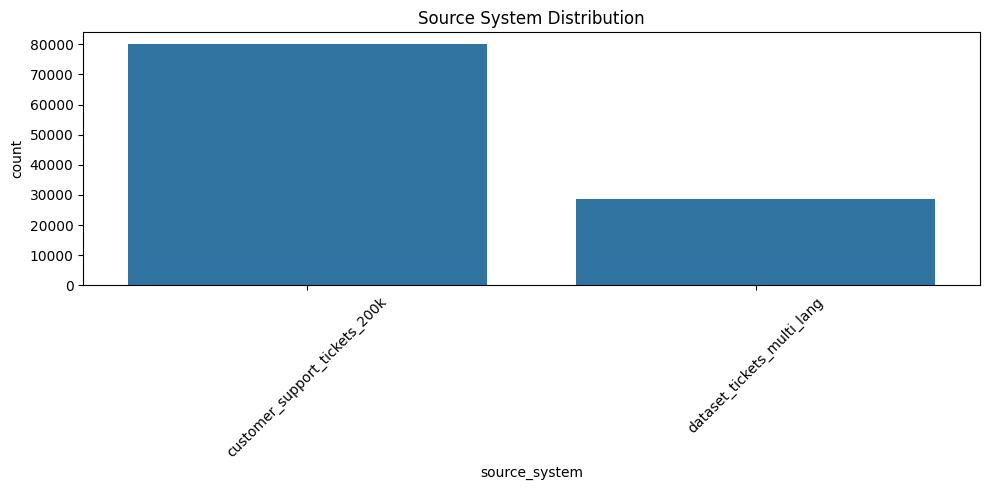

In [13]:
# ============================================================
# CELL 11 — SOURCE SYSTEM DISTRIBUTION
# ============================================================
if "source_system" in df.columns:

    plt.figure(figsize=(10, 5))

    sns.countplot(
        data=df,
        x="source_system",
        order=df["source_system"].value_counts().index
    )

    plt.title("Source System Distribution")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


In [14]:
# ============================================================
# CELL 12 — TEXT LENGTH STATISTICS (Problem + Solution)
# ============================================================
PROBLEM_COLUMN = "problem_text"
SOLUTION_COLUMN = "solution_text"

if PROBLEM_COLUMN in df.columns and SOLUTION_COLUMN in df.columns:

    df["problem_text_length"] = (
        df[PROBLEM_COLUMN]
        .fillna("")
        .astype(str)
        .str.len()
    )

    df["solution_text_length"] = (
        df[SOLUTION_COLUMN]
        .fillna("")
        .astype(str)
        .str.len()
    )

    print("=" * 60)
    print("PROBLEM TEXT LENGTH STATISTICS")
    print("=" * 60)
    print(df["problem_text_length"].describe())

    print("\n" + "=" * 60)
    print("SOLUTION TEXT LENGTH STATISTICS")
    print("=" * 60)
    print(df["solution_text_length"].describe())

else:
    print(f"{PROBLEM_COLUMN} and/or {SOLUTION_COLUMN} column not found.")


PROBLEM TEXT LENGTH STATISTICS
count    108536.000000
mean        210.144450
std         165.921022
min          23.000000
25%         127.000000
50%         143.000000
75%         159.000000
max        1526.000000
Name: problem_text_length, dtype: float64

SOLUTION TEXT LENGTH STATISTICS
count    108536.000000
mean        152.832857
std         168.831042
min          20.000000
25%          63.000000
50%          72.000000
75%         110.000000
max        1006.000000
Name: solution_text_length, dtype: float64


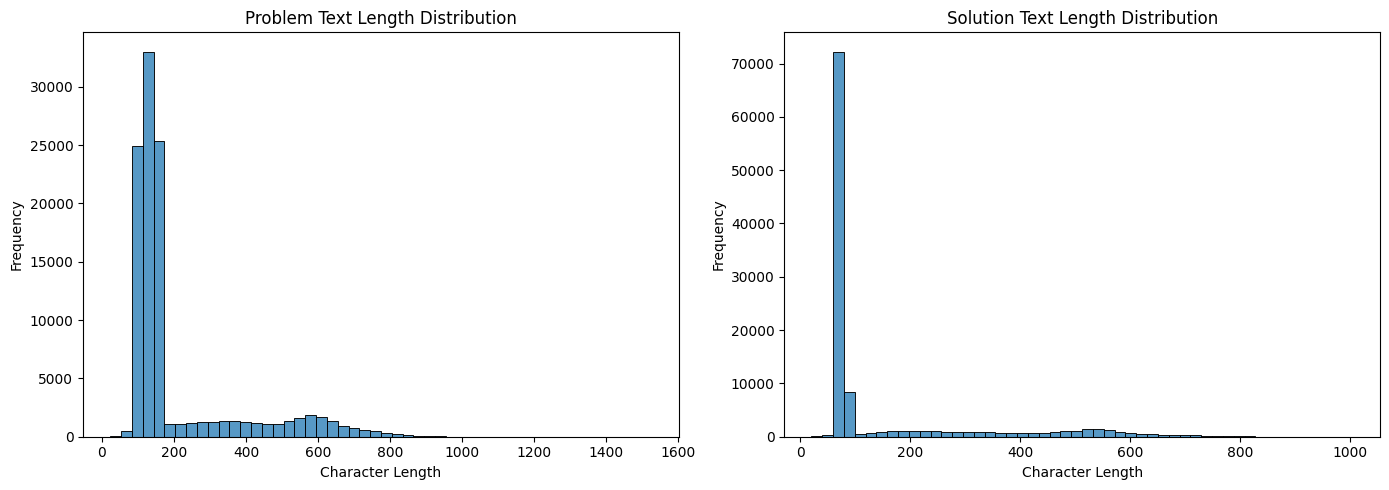

In [15]:
# ============================================================
# CELL 13 — PROBLEM vs SOLUTION TEXT LENGTH DISTRIBUTION
# ============================================================
if "problem_text_length" in df.columns and "solution_text_length" in df.columns:

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(
        df["problem_text_length"],
        bins=50,
        ax=axes[0]
    )
    axes[0].set_title("Problem Text Length Distribution")
    axes[0].set_xlabel("Character Length")
    axes[0].set_ylabel("Frequency")

    sns.histplot(
        df["solution_text_length"],
        bins=50,
        ax=axes[1]
    )
    axes[1].set_title("Solution Text Length Distribution")
    axes[1].set_xlabel("Character Length")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

else:
    print("problem_text_length and/or solution_text_length columns not found.")


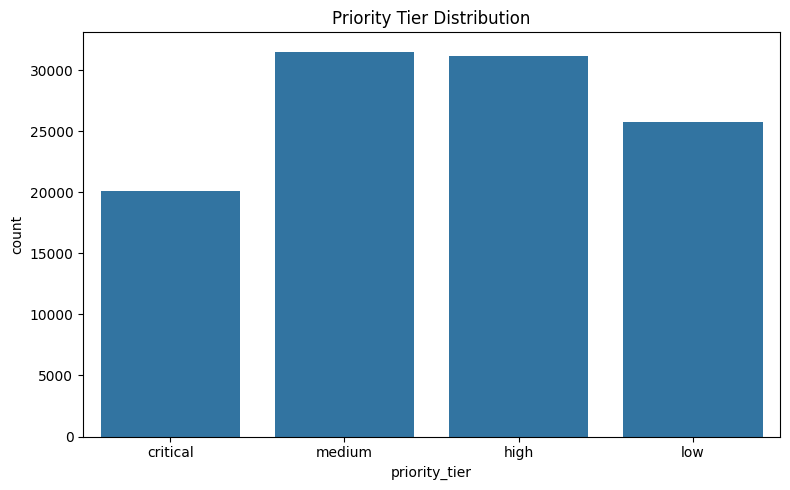

In [16]:
# ============================================================
# CELL 14 — PRIORITY TIER DISTRIBUTION
# ============================================================
if "priority_tier" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x="priority_tier"
    )

    plt.title("Priority Tier Distribution")

    plt.tight_layout()
    plt.show()

else:
    print("priority_tier column not found.")


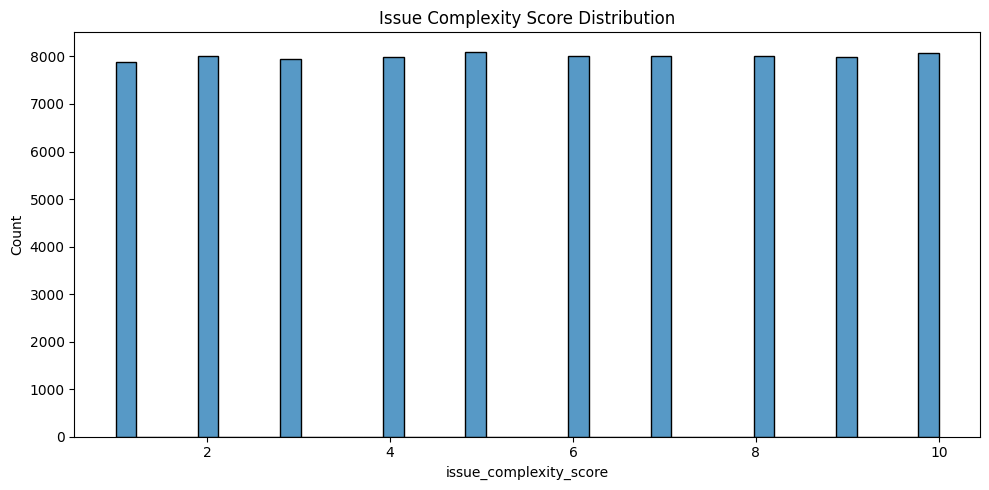

In [19]:
# ============================================================
# CELL 17 — ISSUE COMPLEXITY SCORE DISTRIBUTION
# ============================================================
if "issue_complexity_score" in df.columns:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        df["issue_complexity_score"].dropna(),
        bins=40
    )

    plt.title("Issue Complexity Score Distribution")

    plt.tight_layout()
    plt.show()

else:
    print("issue_complexity_score column not found.")


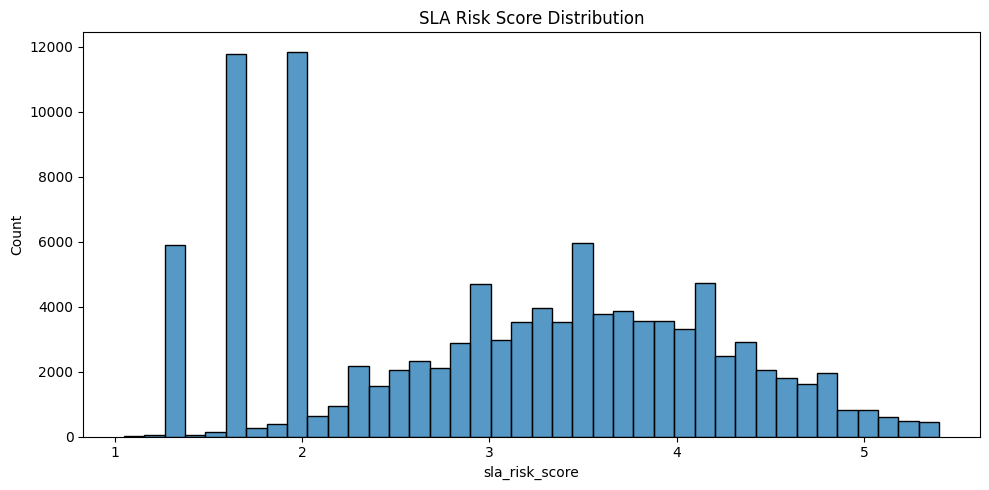

In [20]:
# ============================================================
# CELL 18 — SLA RISK SCORE DISTRIBUTION
# ============================================================
if "sla_risk_score" in df.columns:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        df["sla_risk_score"].dropna(),
        bins=40
    )

    plt.title("SLA Risk Score Distribution")

    plt.tight_layout()
    plt.show()

else:
    print("sla_risk_score column not found.")


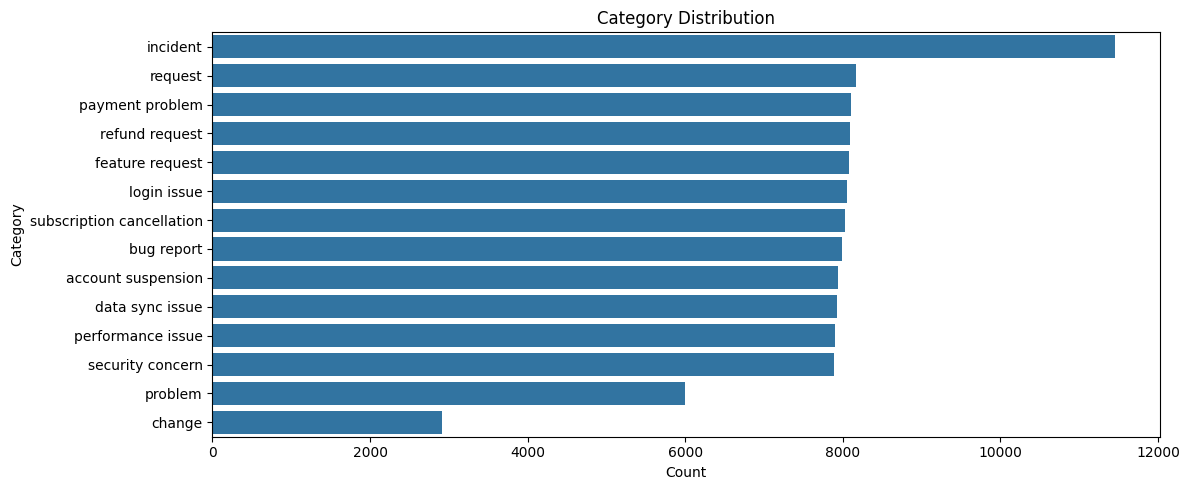


Top Categories:
category
incident                     11453
request                       8164
payment problem               8100
refund request                8086
feature request               8081
login issue                   8056
subscription cancellation     8034
bug report                    7989
account suspension            7939
data sync issue               7931


In [21]:
# ============================================================
# CELL 19 — CATEGORY DISTRIBUTION
# ============================================================
if "category" in df.columns:

    plt.figure(figsize=(12, 5))

    cat_counts = df["category"].value_counts()

    sns.barplot(
        x=cat_counts.values,
        y=cat_counts.index
    )

    plt.title("Category Distribution")
    plt.xlabel("Count")
    plt.ylabel("Category")

    plt.tight_layout()
    plt.show()

    print("\nTop Categories:")
    print(cat_counts.head(10).to_string())

else:
    print("category column not found.")


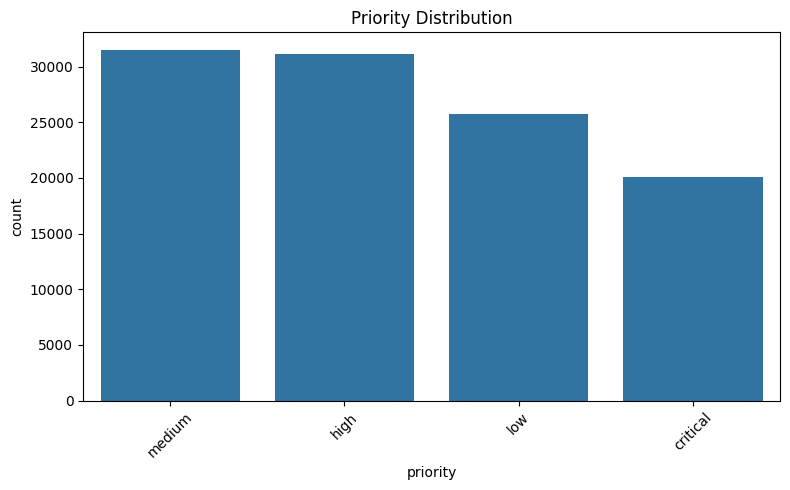

In [22]:
# ============================================================
# CELL 20 — PRIORITY DISTRIBUTION
# ============================================================
if "priority" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x="priority",
        order=df["priority"].value_counts().index
    )

    plt.title("Priority Distribution")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

else:
    print("priority column not found.")


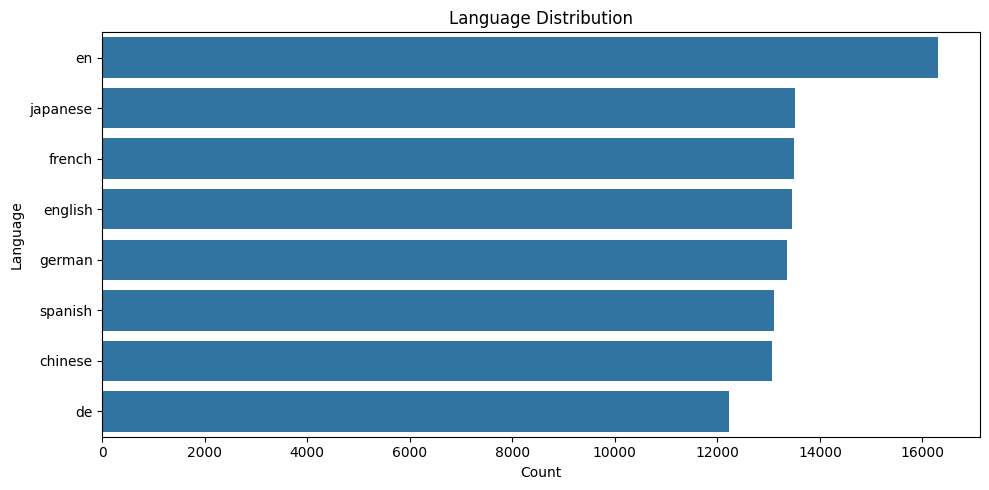

In [23]:
# ============================================================
# CELL 21 — LANGUAGE DISTRIBUTION
# ============================================================
if "language" in df.columns:

    plt.figure(figsize=(10, 5))

    lang_counts = df["language"].value_counts()

    sns.barplot(
        x=lang_counts.values,
        y=lang_counts.index
    )

    plt.title("Language Distribution")
    plt.xlabel("Count")
    plt.ylabel("Language")

    plt.tight_layout()
    plt.show()

else:
    print("language column not found.")


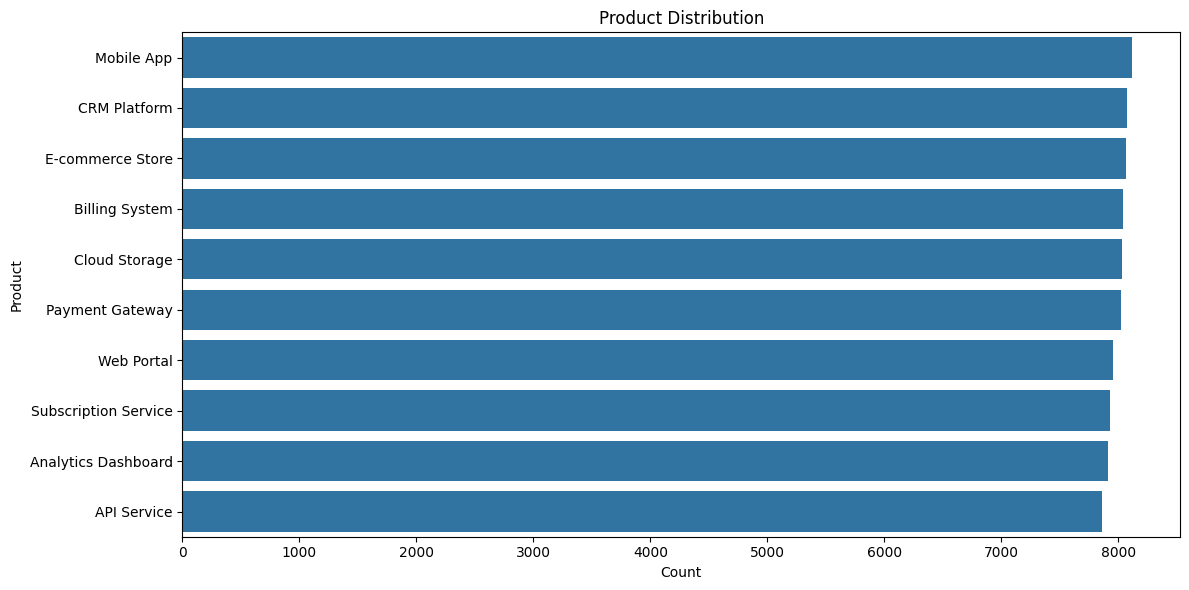

In [24]:
# ============================================================
# CELL 22 — PRODUCT DISTRIBUTION
# ============================================================
if "product" in df.columns:

    plt.figure(figsize=(12, 6))

    prod_counts = df["product"].value_counts()

    sns.barplot(
        x=prod_counts.values,
        y=prod_counts.index
    )

    plt.title("Product Distribution")
    plt.xlabel("Count")
    plt.ylabel("Product")

    plt.tight_layout()
    plt.show()

else:
    print("product column not found.")


SLA & ESCALATION OVERVIEW

--- is_sla_breached ---
is_sla_breached
0    68556
1    39980
Name: count, dtype: int64
Breached rate: 36.84%

--- is_escalated ---
is_escalated
0    68413
1    40123
Name: count, dtype: int64
Escalation rate: 36.97%

--- escalation_risk_level ---
escalation_risk_level
low       100957
medium      7579
Name: count, dtype: int64


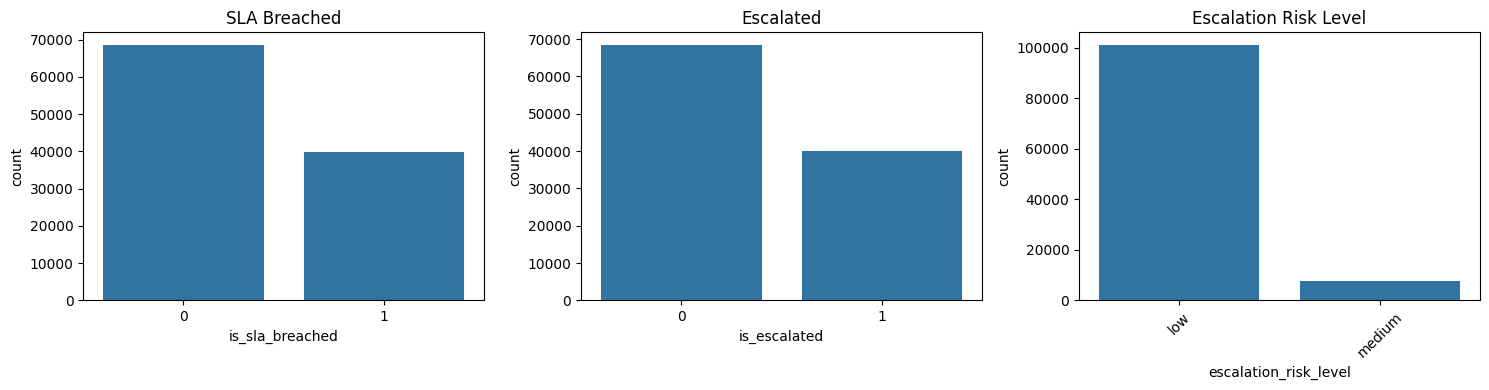

In [25]:
# ============================================================
# CELL 23 — SLA & ESCALATION DISTRIBUTION
# ============================================================
print("=" * 60)
print("SLA & ESCALATION OVERVIEW")
print("=" * 60)

if "is_sla_breached" in df.columns:
    print("\n--- is_sla_breached ---")
    print(df["is_sla_breached"].value_counts())
    print(f"Breached rate: {df['is_sla_breached'].mean() * 100:.2f}%")

if "is_escalated" in df.columns:
    print("\n--- is_escalated ---")
    print(df["is_escalated"].value_counts())
    print(f"Escalation rate: {df['is_escalated'].mean() * 100:.2f}%")

if "escalation_risk_level" in df.columns:
    print("\n--- escalation_risk_level ---")
    print(df["escalation_risk_level"].value_counts())

if "is_sla_breached" in df.columns and "is_escalated" in df.columns:

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    if "is_sla_breached" in df.columns:
        sns.countplot(data=df, x="is_sla_breached", ax=axes[0])
        axes[0].set_title("SLA Breached")

    if "is_escalated" in df.columns:
        sns.countplot(data=df, x="is_escalated", ax=axes[1])
        axes[1].set_title("Escalated")

    if "escalation_risk_level" in df.columns:
        sns.countplot(
            data=df,
            x="escalation_risk_level",
            order=sorted(df["escalation_risk_level"].dropna().unique()),
            ax=axes[2]
        )
        axes[2].set_title("Escalation Risk Level")
        axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


In [26]:
# ============================================================
# CELL 24 — GOLD ROWS (BOTH TEXT FIELDS POPULATED)
# ============================================================
print("=" * 60)
print("GOLD ROWS ANALYSIS")
print("=" * 60)

if "problem_text" in df.columns and "solution_text" in df.columns:

    has_problem = df["problem_text"].notna()
    has_solution = df["solution_text"].notna()
    both_populated = has_problem & has_solution
    either_populated = has_problem | has_solution

    print(f"Rows with problem_text populated : {has_problem.sum():,}")
    print(f"Rows with solution_text populated : {has_solution.sum():,}")
    print(f"Rows with BOTH populated (gold)   : {both_populated.sum():,}")
    print(f"Rows with EITHER populated        : {either_populated.sum():,}")

    gold_pct = both_populated.sum() / len(df) * 100
    print(f"Gold row percentage               : {gold_pct:.2f}%")

else:
    print("problem_text and/or solution_text columns not found.")


GOLD ROWS ANALYSIS
Rows with problem_text populated : 108,536
Rows with solution_text populated : 108,536
Rows with BOTH populated (gold)   : 108,536
Rows with EITHER populated        : 108,536
Gold row percentage               : 100.00%


SOURCE DATASET BREAKDOWN


,source_dataset,count
0,customer_support_tickets_200k,79999
1,dataset_tickets_multi_lang,28537


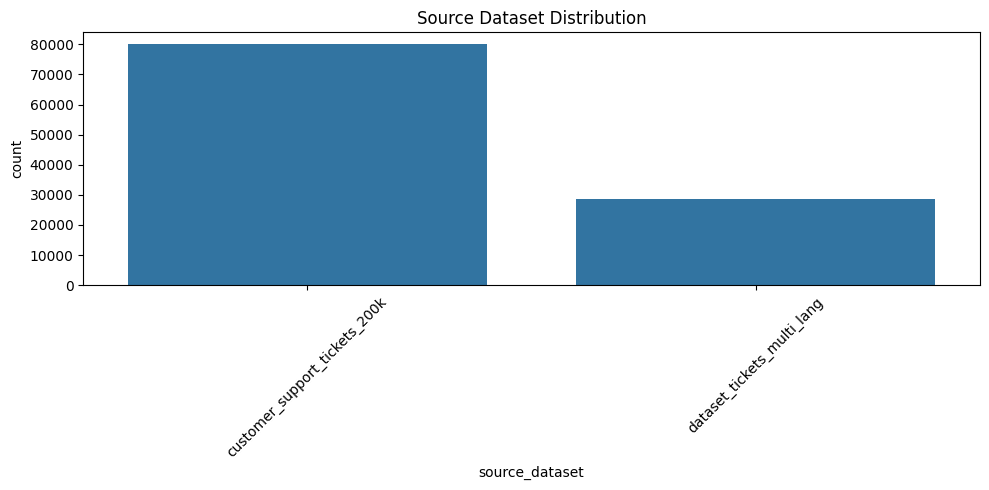


SOURCE SYSTEM BREAKDOWN


,source_system,count
0,customer_support_tickets_200k,79999
1,dataset_tickets_multi_lang,28537


In [27]:
# ============================================================
# CELL 25 — SOURCE DATASET BREAKDOWN
# ============================================================
if "source_dataset" in df.columns:

    print("=" * 60)
    print("SOURCE DATASET BREAKDOWN")
    print("=" * 60)

    ds_counts = (
        df["source_dataset"]
        .value_counts()
        .reset_index()
    )
    ds_counts.columns = ["source_dataset", "count"]

    display(ds_counts)

    plt.figure(figsize=(10, 5))

    sns.countplot(
        data=df,
        x="source_dataset",
        order=df["source_dataset"].value_counts().index
    )

    plt.title("Source Dataset Distribution")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

else:
    print("source_dataset column not found.")

if "source_system" in df.columns:

    print("\n" + "=" * 60)
    print("SOURCE SYSTEM BREAKDOWN")
    print("=" * 60)

    sys_counts = (
        df["source_system"]
        .value_counts()
        .reset_index()
    )
    sys_counts.columns = ["source_system", "count"]

    display(sys_counts)


In [28]:
# ============================================================
# CELL 26 — DATASET HEALTH SUMMARY
# ============================================================

print("=" * 60)
print("DATASET HEALTH SUMMARY")
print("=" * 60)

print(f"Rows                    : {len(df):,}")
print(f"Columns                 : {df.shape[1]}")
print(f"Memory Usage            : {memory_mb:.2f} MB")

if "rag_id" in df.columns:
    print(f"Duplicate rag_id        : {df.duplicated(subset=['rag_id']).sum():,}")

if "problem_text_length" in df.columns:
    print(f"Avg Problem Text Length : {df['problem_text_length'].mean():.2f}")
    print(f"Median Problem Text Len : {df['problem_text_length'].median():.2f}")

if "solution_text_length" in df.columns:
    print(f"Avg Solution Text Length: {df['solution_text_length'].mean():.2f}")
    print(f"Median Solution Text Len: {df['solution_text_length'].median():.2f}")

print("\nTop Missing Columns:")
display(nulls.head(10))


DATASET HEALTH SUMMARY
Rows                    : 108,536
Columns                 : 49
Memory Usage            : 103.48 MB
Duplicate rag_id        : 0
Avg Problem Text Length : 210.14
Median Problem Text Len : 143.00
Avg Solution Text Length: 152.83
Median Solution Text Len: 72.00

Top Missing Columns:


,column,null_count,null_percentage
0,waiting_duration,108536,100.00
1,urgency_tier,108536,100.00
2,impact_tier,108536,100.00
3,tag_8,107974,99.48
4,tag_7,106501,98.13
5,tag_6,102675,94.60
6,tag_5,94018,86.62
7,tag_4,83047,76.52
8,tag_3,80133,73.83
9,tag_2,80012,73.72


In [30]:
# ============================================================
# CELL 27 — SAVE BASIC REPORT
# ============================================================

report = {
    "rows": len(df),
    "columns": df.shape[1],
    "memory_mb": round(memory_mb, 2),
}

report_df = pd.DataFrame([report])

report_df.to_csv(
    "../../evaluation_v2/data_understanding_report_v2.csv",
    index=False
)

print("Basic report exported successfully.")


Basic report exported successfully.
